In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

In [3]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
mu = 1.5 * t * np.ones(lattice.X)
T = 0.01

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5* t
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=V_prime, V=None,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j])

In [4]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1, maxiter=200, verbose=False, temperature=T)

Converged after 167 iterations


In [5]:
F, Fuu, Fdd = H.get_correlations()

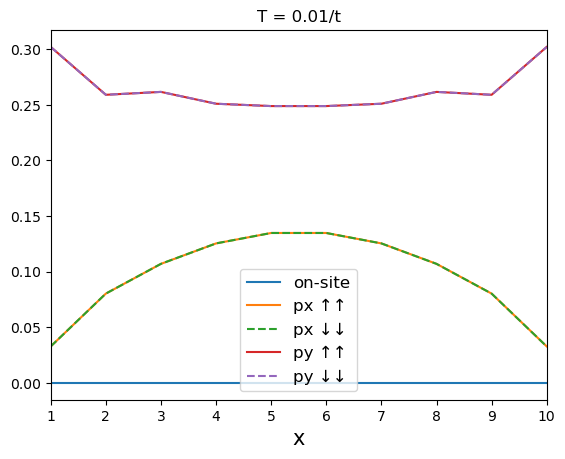

In [6]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(Fuu.px), label="px ↑↑")
plt.plot(x, np.real(Fdd.px), "--", label="px ↓↓")
plt.plot(x, np.imag(Fuu.py), label="py ↑↑")
plt.plot(x, np.imag(Fdd.py), "--", label="py ↓↓")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

### NP

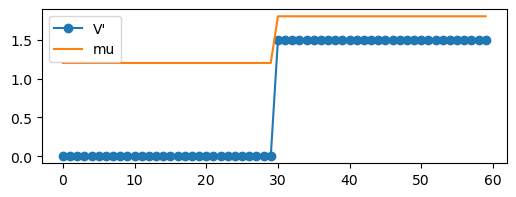

In [9]:
widthN = 30
widthP = 30

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T = 0.02
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:] = muP

U = None
V = None

V0 = 1.5 * t
V_prime = V0 * np.ones(lattice.X)
V_prime[:widthN] = 0 

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [10]:
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=V_prime, V=None,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j])

In [11]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1, atol=1e-3, maxiter=100, verbose=False, temperature=T)
F, Fuu, Fdd = H.get_correlations()

Converged after 14 iterations


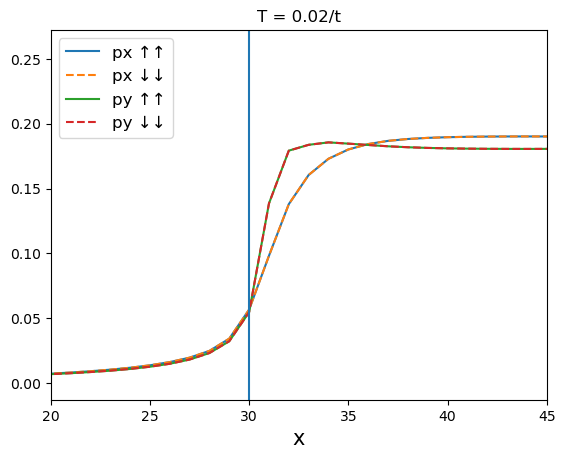

In [12]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(Fuu.px), label="px ↑↑")
plt.plot(x, np.real(Fdd.px), "--", label="px ↓↓")
plt.plot(x, np.imag(Fuu.py), label="py ↑↑")
plt.plot(x, np.imag(Fdd.py), "--", label="py ↓↓")
plt.axvline(widthN)
plt.xlabel("x", fontsize=15)
plt.xlim(20, 45)
plt.legend(fontsize=12, loc="best")

### SFP

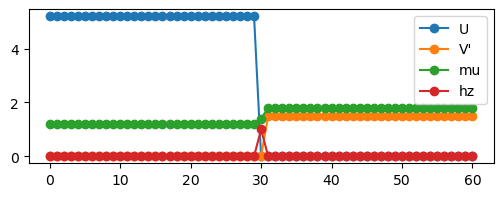

In [8]:
widthS = 30
widthF = 1
widthP = 30

X, Y = widthS+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.02

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:widthS + widthF + widthP] = muP

hz0 = 1 * t
hz = np.zeros_like(mu)
hz[widthS:widthS + widthF] = hz0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0

V0 = 1.5 * t
V_prime = V0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0 

V = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')

plt.legend()

In [15]:
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=V_prime, V=None,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=hz, F0_init=0.1)

In [20]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1, atol=1e-3, maxiter=100, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.000611902202947029
Relative error: 0.007388590092843083
Average old: (0.4525851574716636+0.011131874033246362j)
Average: (0.4525828127587417+0.011157390967937367j)
F_xplus:
Absolute error: 2.6836787275693732e-05
Relative error: 0.007187572768622645
Average old: (-0.016513745782338524-0.0006720840954103637j)
Average: (-0.016513642209220903-0.0006730846162911905j)
F_xmin:
Absolute error: 2.6849755519567183e-05
Relative error: 0.007190649667917876
Average old: (-0.016514502387685284-0.0006725873512565876j)
Average: (-0.016514399117490912-0.0006735874880429872j)
F_yplus:
Absolute error: 5.579432148718913e-05
Relative error: 0.007366975184704377
Average old: (-0.018341920942314474-0.0007479169177472027j)
Average: (-0.018342048137866624-0.0007485972155724086j)
F_ymin:
Absolute error: 5.5794321489048146e-05
Relative error: 0.007369292440502374
Average old: (-0.01834192094231457-0.0007479169177458008j)
Average: (-0.018342048137866558-0.0007485972155739599j)
Fuu_xplus:
Abs

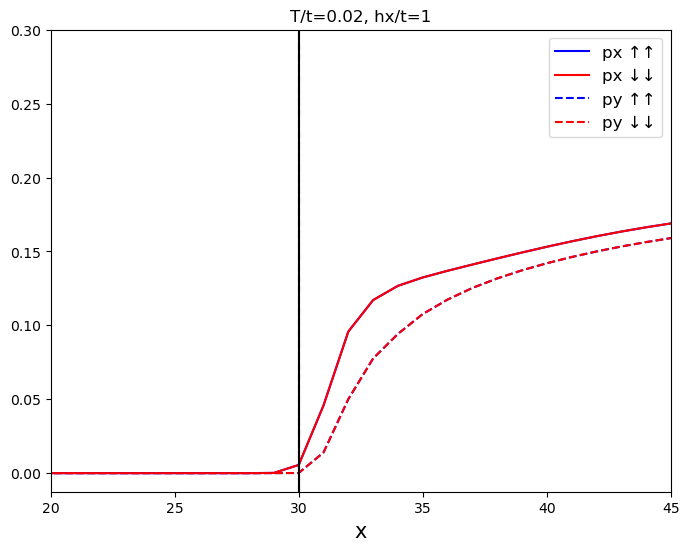

In [21]:
x = np.arange(1, widthS + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={hz0}")
axs.plot(x, np.real(Fuu.px), label="px ↑↑", color="blue")
axs.plot(x, np.real(Fdd.px), label="px ↓↓", color="red")
axs.plot(x, np.imag(Fuu.py), "--", label="py ↑↑", color="blue")
axs.plot(x, np.imag(Fdd.py), "--", label="py ↓↓", color="red")
axs.axvline(widthS, color='black', linestyle='--')
axs.axvline(widthS, color="k")
plt.xlabel("x", fontsize=15)
plt.xlim(20, 45)
plt.ylim(None, 0.30)
plt.legend(fontsize=12, loc="best")

### Bulk with B field